#Loading Dataset

In [40]:
from google.colab import drive
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [41]:
drive.mount('/content/drive')
# ---- Config (edit here only) ----
DATA_DIR = '/content/drive/MyDrive/BTT_Amazon1A_Studio'
RAW_XLSX = f'{DATA_DIR}/online_retail_II.xlsx'

# Keep printed tables compact (2 decimals, thousands separators)
pd.set_option('display.float_format', '{:,.2f}'.format)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [42]:
sheets = pd.read_excel(RAW_XLSX, sheet_name=None)   # sheet_name=None -> dict of all sheets
print("Sheets found:", list(sheets.keys()))
df = pd.concat(sheets.values(), ignore_index=True)

print(f"Rows: {len(df):,}")
print(f"Date range: {df['InvoiceDate'].min()}  ->  {df['InvoiceDate'].max()}")

Sheets found: ['Year 2009-2010', 'Year 2010-2011']
Rows: 1,067,371
Date range: 2009-12-01 07:45:00  ->  2011-12-09 12:50:00


In [ ]:
#!wget https://raw.githubusercontent.com/Break-Through-Tech/Amazon-1A-discovering-customer-lifecycle-states-and-behavioral-drift-for-early-churn-detection/refs/heads/main/data/online_retail_II.csv

In [43]:
df.shape

(1067371, 8)

In [44]:
df.dtypes

,0
Invoice,object
Customer ID,float64
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[ns]
Price,float64
Country,object


#Data Preparation

In [45]:
null_counts = df.isnull().sum().sort_values(ascending=False)
print(null_counts)

Customer ID    243007
Description      4382
Invoice             0
StockCode           0
Quantity            0
InvoiceDate         0
Price               0
Country             0
dtype: int64


In [46]:
# Drop rows with no Customer ID
rows_before = len(df)
df = df.dropna(subset=['Customer ID']).copy()
print(f"Dropped {rows_before - len(df):,} rows with missing Customer ID")

# Fix types:
df['Customer ID'] = df['Customer ID'].astype(float).astype(int).astype(str)
df['StockCode'] = df['StockCode'].astype(str)   # mixed numbers/text in the raw file

# Remove duplicate rows
rows_before = len(df)
df = df.drop_duplicates()
print(f"Dropped {rows_before - len(df):,} duplicate rows")

# Dates, revenue, and the month each transaction belongs to
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Revenue'] = df['Quantity'] * df['Price']
df['SnapshotMonth'] = df['InvoiceDate'].dt.to_period('M')

Dropped 243,007 rows with missing Customer ID
Dropped 26,479 duplicate rows


In [47]:
df.head()

,Invoice,Customer ID,StockCode,Description,Quantity,InvoiceDate,Price,Country,Revenue,SnapshotMonth
0,489434,13085,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,United Kingdom,83.40,2009-12
1,489434,13085,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,United Kingdom,81.00,2009-12
2,489434,13085,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,United Kingdom,81.00,2009-12
3,489434,13085,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,United Kingdom,100.80,2009-12
4,489434,13085,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,United Kingdom,30.00,2009-12


In [48]:
df.shape

(797885, 10)

## Handling Cancellations/Returns

###option 1 : netting

In [49]:
'''
cols: 'Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country']
'''
df['IsCancellation'] = df['Invoice'].astype(str).str.startswith('C') # if taking cancellations as invoice codes starting with C

# Net out returns/cancellations first per customer, product, and month
netted = df.groupby(['Customer ID', 'StockCode', 'SnapshotMonth']).agg(
    Quantity=('Quantity', 'sum'),
    Price=('Price', 'first'),
    Invoice=('Invoice', 'first'),
    Description=('Description', 'first'),
    Country=('Country', 'first'),
    InvoiceDate=('InvoiceDate', 'first'),
    CancelCount=('IsCancellation', 'sum'),
    Revenue=('Revenue', 'sum')
).reset_index()

In [50]:
netted[netted["CancelCount"]>0].shape

(17543, 11)

In [51]:
#df[df['StockCode'] == "C2"].head()# often surfaces rare/weird codes

### option 2 : Maintaining seperate purchase table and canceled table?


In [52]:
#df['is_cancel'] = df['Invoice'].astype(str).str.startswith('C')
#purchases     = df[~df['is_cancel'] & (df['Quantity'] > 0) & (df['Price'] > 0)]
#cancellations = df[df['is_cancel']]

#print(purchases.shape)
#print(cancellations.shape)

(779425, 12)
(18390, 12)


##Monthly Features

In [54]:
monthly_data = netted.groupby(['Customer ID', 'SnapshotMonth']).agg(
    month_orders=('Invoice', 'nunique'),
    month_revenue=('Revenue', 'sum'),
    month_quantity=('Quantity', 'sum'),
    month_diff_items=('StockCode', 'nunique'),
    month_last_order=('InvoiceDate', 'max'),
    month_cancellations=('CancelCount', 'sum')

).reset_index() #all features coming from the netted table

In [55]:
monthly_data['cancellation_rate'] = monthly_data['month_cancellations'] / monthly_data['month_orders']

##Customer-Month Panel

In [57]:
#All calender months in the dataset
all_periods = pd.period_range(monthly_data['SnapshotMonth'].min(),
                              monthly_data['SnapshotMonth'].max(), freq='M')

In [58]:
# Each customer gets a row for every month starting at their first month
customer_first_period = df.groupby('Customer ID')['SnapshotMonth'].min()
records=[]
for customer_id, first_period in customer_first_period.items():
    valid_periods = all_periods[all_periods >= first_period]
    for period in valid_periods:
        records.append((customer_id, period))
feature_table = pd.DataFrame(records, columns=['Customer ID', 'SnapshotMonth'])

In [59]:
# Attach monthly features; months with no activity have no match -> fill with 0
feature_table = feature_table.merge(monthly_data, on=['Customer ID', 'SnapshotMonth'], how='left')
MONTHLY_FEATURES = ['month_orders', 'month_revenue', 'month_quantity',
                    'month_diff_items', 'month_cancellations']
feature_table[MONTHLY_FEATURES] = feature_table[MONTHLY_FEATURES].fillna(0)

##90-Day Churn Label

In [60]:
# All dates on which each customer transacted
purchase_dates = df.groupby('Customer ID')['InvoiceDate'].unique()
data_end = df['InvoiceDate'].max()

churn = []
for customer_id, period in zip(feature_table['Customer ID'], feature_table['SnapshotMonth']):
    month_end = period.end_time
    window_end = month_end + pd.Timedelta(days=90)

    if window_end > data_end: # full window not observed -> can't label
        churn.append(None)
        continue

    dates = purchase_dates[customer_id]
    bought = ((dates > month_end) & (dates <= window_end)).any()
    churn.append(0 if bought else 1)

feature_table['churn'] = churn

In [61]:
#handling churned customers
first_churn = (
    feature_table[feature_table['churn'] == 1]
    .groupby('Customer ID')['SnapshotMonth']
    .min()
    .rename('first_churn_month')
)

# Keep never-churned customers' rows, plus rows up to the first churn month
feature_table = feature_table.merge(first_churn, on='Customer ID', how='left')
keep = feature_table['first_churn_month'].isna() | (feature_table['SnapshotMonth'] <= feature_table['first_churn_month'])
feature_table = feature_table[keep].drop(columns='first_churn_month').copy()

In [62]:
feature_table.shape

(25370, 10)

In [63]:
# Final labeled table: drop months that couldn't be labeled
labeled_table = feature_table.dropna(subset=['churn']).copy()
labeled_table['churn'] = labeled_table['churn'].astype(int)

# Exploratory Data Analysis

## Churn Distribution

Churn counts:
churn
0    16412
1     4707
Name: count, dtype: int64

Churn percentages:
churn
0   77.71
1   22.29
Name: proportion, dtype: float64


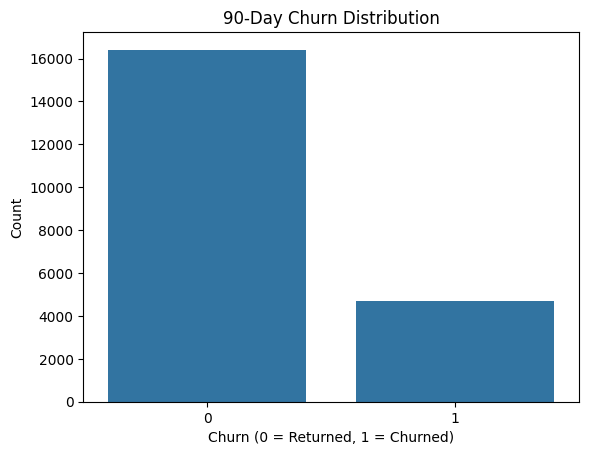

In [64]:
# explore the data
labeled_table.describe(include='all')

# examine churn distribution
churn_counts = labeled_table['churn'].value_counts().sort_index()
churn_percent = labeled_table['churn'].value_counts(normalize=True).sort_index() * 100

print("Churn counts:")
print(churn_counts)

print("\nChurn percentages:")
print(churn_percent.round(2))

sns.countplot(data=labeled_table, x='churn')
plt.title('90-Day Churn Distribution')
plt.xlabel('Churn (0 = Returned, 1 = Churned)')
plt.ylabel('Count')
plt.show()

## Features by churn status

,month_orders,month_revenue,month_quantity,month_diff_items,month_cancellations,cancellation_rate
churn,,,,,,
0,1.20,548.75,336.15,20.73,0.59,0.44
1,1.17,321.21,237.05,20.81,0.51,0.40


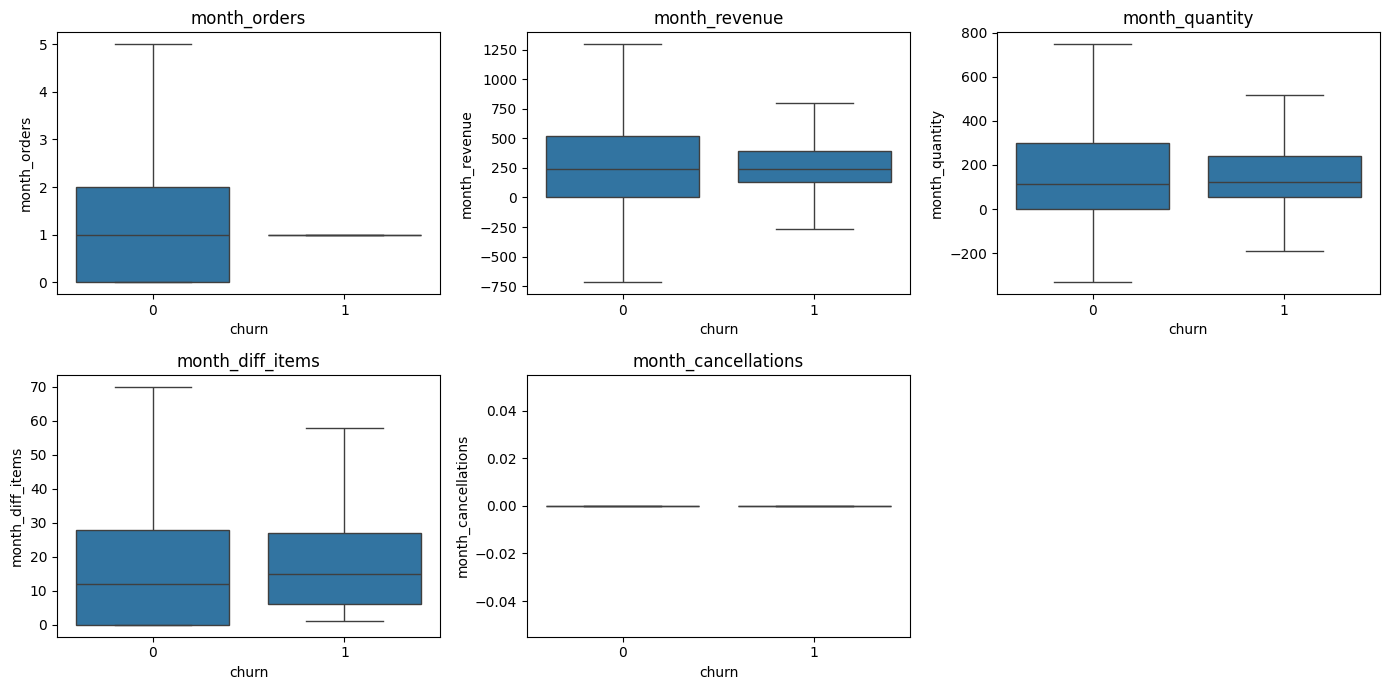

In [65]:
# Average feature values for returning (0) vs churned (1) customer-months
display(labeled_table.groupby('churn')[MONTHLY_FEATURES + ['cancellation_rate']].mean().round(2))

# Distributions side by side (outliers hidden so the boxes stay readable)
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flat, MONTHLY_FEATURES):
    sns.boxplot(data=labeled_table, x='churn', y=col, showfliers=False, ax=ax)
    ax.set_title(col)
axes.flat[-1].axis('off')   # 5 features, 6 slots
plt.tight_layout()
plt.show()

## Correlations with Churn

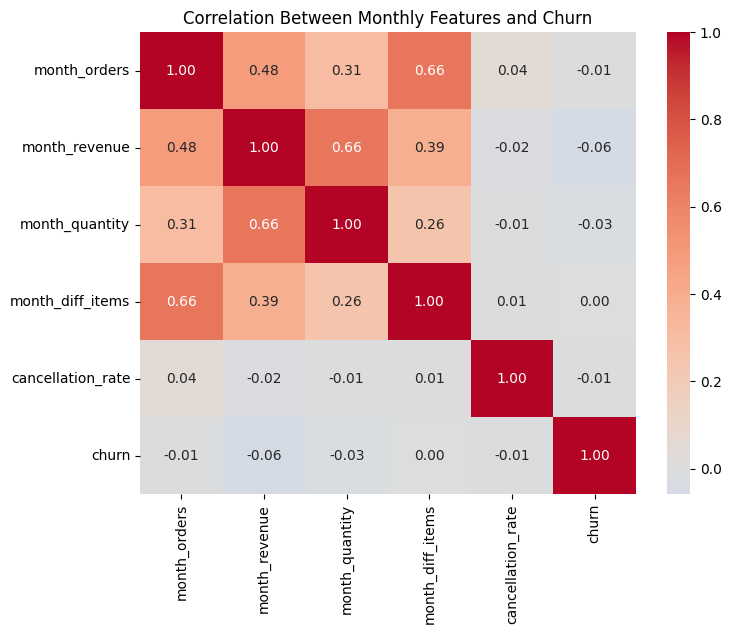

,corr_with_churn
month_revenue,-0.06
month_quantity,-0.03
cancellation_rate,-0.01
month_orders,-0.01
month_diff_items,0.00


In [66]:
CORR_COLS = ['month_orders', 'month_revenue', 'month_quantity',
             'month_diff_items', 'cancellation_rate', 'churn']
corr = labeled_table[CORR_COLS].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Between Monthly Features and Churn')
plt.show()

# Features ranked by strength of correlation with churn
display(corr['churn'].drop('churn').sort_values(key=abs, ascending=False)
        .round(3).to_frame('corr_with_churn'))

## Cancellations vs churn

In [67]:
# Compare churn rate in months with vs without a cancellation
had_cancellation = (labeled_table['month_cancellations'] > 0).rename('had_cancellation')
cancel_summary = (labeled_table.groupby(had_cancellation)['churn']
                  .agg(rows='size', churners='sum', churn_rate_pct='mean'))
cancel_summary['churn_rate_pct'] *= 100
display(cancel_summary)

,rows,churners,churn_rate_pct
had_cancellation,,,
False,16955,3773,22.25
True,4164,934,22.43


#Feature Engineering

In [68]:
# One row per completed order (drop returns/cancellations)
orders = (
    df[df['Quantity'] > 0]
    .groupby(['Customer ID', 'Invoice'], as_index=False)['InvoiceDate'].min()
    .sort_values('InvoiceDate')
)
orders['total_orders'] = orders.groupby('Customer ID').cumcount() + 1
orders['first_order'] = orders.groupby('Customer ID')['InvoiceDate'].transform('min')
orders = orders.rename(columns={'InvoiceDate': 'last_order'})

# End of each snapshot month
labeled_table['snapshot_end'] = (
    pd.to_datetime(labeled_table['SnapshotMonth'].astype(str))
    .dt.to_period('M').dt.end_time.dt.normalize()
)

# For each customer snapshot, grab their most recent order on or before snapshot_end
labeled_table = labeled_table.sort_values('snapshot_end')
feat = pd.merge_asof(
    labeled_table,
    orders[['Customer ID', 'last_order', 'first_order', 'total_orders']],
    left_on='snapshot_end', right_on='last_order',
    by='Customer ID', direction='backward'
)

feat['tenure_days']  = (feat['snapshot_end'] - feat['first_order']).dt.days
feat['recency_days'] = (feat['snapshot_end'] - feat['last_order']).dt.days
feat['frequency']    = feat['total_orders'] / (feat['tenure_days'].clip(lower=30) / 30)  # orders per month

In [71]:
#finding orders in 30,60 and 90 days
for days in [30, 60, 90]:

    feat['start_col'] = feat['snapshot_end'] - pd.Timedelta(days=days)

    previous = pd.merge_asof(
        feat[['Customer ID', 'start_col']].sort_values('start_col'),
        orders[['Customer ID', 'last_order', 'total_orders']],
        left_on='start_col',
        right_on='last_order',
        by='Customer ID',
        direction='backward'
    ).rename(columns={'total_orders': 'before_col'})

    feat = feat.merge(
        previous[['Customer ID', 'start_col', 'before_col']],
        on=['Customer ID', 'start_col'],
        how='left'
    )

    feat[f'orders_{days}d'] = feat['total_orders'].fillna(0) - feat['before_col'].fillna(0)

    #Remove temporary columns
    feat = feat.drop(columns=['start_col', 'before_col'])

In [72]:
feat.head()

,Customer ID,SnapshotMonth,month_orders,month_revenue,month_quantity,month_diff_items,month_last_order,month_cancellations,cancellation_rate,churn,snapshot_end,last_order,first_order,total_orders,tenure_days,recency_days,frequency,orders_30d,orders_60d,orders_90d
0,12346,2009-12,2.00,113.50,26.00,2.00,2009-12-18 10:55:00,0.00,0.00,0,2009-12-31,2009-12-18 10:55:00,2009-12-14 08:34:00,5.00,16.00,12.00,5.00,5.00,5.00,5.00
1,14606,2009-12,11.00,"1,401.59",527.00,210.00,2009-12-21 14:33:00,12.00,1.09,0,2009-12-31,2009-12-21 14:33:00,2009-12-03 12:40:00,8.00,27.00,9.00,8.00,8.00,8.00,8.00
2,14605,2009-12,1.00,208.60,133.00,31.00,2009-12-08 13:59:00,0.00,0.00,1,2009-12-31,2009-12-08 14:01:00,2009-12-08 13:59:00,2.00,22.00,22.00,2.00,2.00,2.00,2.00
3,14593,2009-12,1.00,391.68,157.00,65.00,2009-12-09 12:57:00,2.00,2.00,0,2009-12-31,2009-12-09 12:57:00,2009-12-09 12:57:00,1.00,21.00,21.00,1.00,1.00,1.00,1.00
4,14590,2009-12,3.00,349.66,108.00,38.00,2009-12-16 11:26:00,0.00,0.00,0,2009-12-31,2009-12-16 11:26:00,2009-12-07 14:10:00,3.00,23.00,14.00,3.00,3.00,3.00,3.00


In [73]:
print((feat['orders_30d'] <= feat['orders_60d']).all())
print((feat['orders_60d'] <= feat['orders_90d']).all())

True
True
